In [1]:
import numpy as np
import pingouin as pg



In [6]:
np.random.seed(123)
mean, cov, n = [4, 5], [(1, .6), (.6, 1)], 30
x, y = np.random.multivariate_normal(mean, cov, n).T

# T-test
pg.ttest(x, y)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.400706,58,two-sided,0.001222,"[-1.68, -0.43]",0.878059,26.155,0.916807


/home/chris/Documents/code/NeuralABC_tools/.venv/lib/python3.12/site-packages/pingouin/plotting.py:573: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["wthn"] = data[within].replace({_ordr: i for i, _ordr in enumerate(order)})


Text(0.5, 1.0, 'Effect of meditation on school performance')

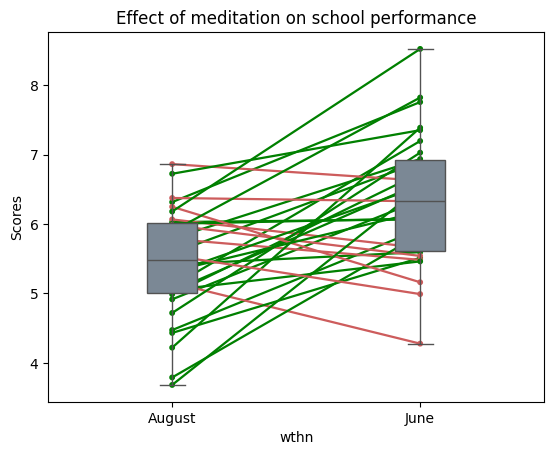

In [7]:
df = pg.read_dataset('mixed_anova').query("Group == 'Meditation' and Time != 'January'")
ax = pg.plot_paired(data=df, dv='Scores', within='Time', subject='Subject')
ax.set_title("Effect of meditation on school performance")

In [ ]:
from pingouin import mediation_analysis, read_dataset
df = read_dataset('mediation')
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=1000)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.083313,0.000000e+00,0.219818,0.537654,Yes


In [ ]:
# add bootstrap samples
df = read_dataset('mediation')
print(len(df))
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=5000)

100


,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.079928,0.000000e+00,0.219475,0.536013,Yes


In [15]:
# add covariates
mediation_analysis(data=df, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.559,0.097,0.000,0.367,0.752,Yes
1,Y ~ M,0.666,0.086,0.000,0.495,0.837,Yes
2,Total,0.420,0.113,0.000,0.196,0.645,Yes
3,Direct,0.064,0.110,0.561,-0.155,0.284,No
4,Indirect,0.356,0.086,0.000,0.209,0.553,Yes


In [19]:
df.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000
mean,5.990000,4.860000,5.230000,0.45,0.530000,1.435000,0.970000
std,1.743646,1.901727,2.039286,0.50,0.501614,0.872721,0.064354
min,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.800000
25%,5.000000,3.000000,4.000000,0.00,0.000000,0.737500,1.000000
50%,6.000000,5.000000,5.000000,0.00,1.000000,1.400000,1.000000
75%,7.000000,6.000000,7.000000,1.00,1.000000,2.162500,1.000000
max,10.000000,10.000000,10.000000,1.00,1.000000,3.000000,1.000000


In [22]:
from scipy.stats import zscore
df_z = df.apply(zscore)
df_z.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,-1.521006e-16,-1.759703e-16,-1.940115e-16,-1.776357e-17,2.220446e-18,-5.551115e-17,5.051515e-16
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,-3.452636e+00,-2.568446e+00,-2.577543e+00,-9.045340e-01,-1.061913e+00,-1.652567e+00,-2.654954e+00
25%,-5.706360e-01,-9.829856e-01,-6.061909e-01,-9.045340e-01,-1.061913e+00,-8.032511e-01,4.685213e-01
50%,5.764000e-03,7.398817e-02,-1.133528e-01,-9.045340e-01,9.416966e-01,-4.030651e-02,4.685213e-01
75%,5.821640e-01,6.024751e-01,8.723235e-01,1.105542e+00,9.416966e-01,8.377996e-01,4.685213e-01
max,2.311364e+00,2.716423e+00,2.350838e+00,1.105542e+00,9.416966e-01,1.802277e+00,4.685213e-01


In [24]:
mediation_analysis(data=df_z, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.513,0.089,0.000,0.337,0.689,Yes
1,Y ~ M,0.621,0.080,0.000,0.462,0.780,Yes
2,Total,0.359,0.097,0.000,0.168,0.551,Yes
3,Direct,0.055,0.094,0.561,-0.132,0.243,No
4,Indirect,0.304,0.074,0.000,0.179,0.473,Yes


# Setup for voxel-based mediation analysis in stroke 

In [172]:
import nibabel as nb
import pandas as pd
import glob
from pathlib import Path
from matplotlib import pyplot as plt
import time



In [67]:
local_extras_dir = '../local_extras/'
image_path = f'{local_extras_dir}/standardized_disconnectomes/'
mask_fname = f'{local_extras_dir}/disconnectome_38sub_WM_mask_no_cerebellum.nii.gz'
bx_df_fname = f'{local_extras_dir}/Demographics_and_Behavioural_Data.csv'



In [86]:
all_images = sorted(glob.glob(f'{image_path}/*.nii.gz'))
df = pd.read_csv(bx_df_fname)
mask = nb.load(mask_fname)
mask_d = mask.get_fdata()>0 #convert t binary

print(f'{len(all_images)} images found')
print(f'{(mask.get_fdata()>0).sum()} voxels in mask')
print(f'df shape: {df.shape}')
df.head()

38 images found
672377 voxels in mask
df shape: (39, 6)


,Subject,Sex (M=0),Age (y),FM-UL Score,APM Task Score,VGR Task Score
0,S01,0,79,17.0,3.29,2.82
1,S02,0,50,4.0,5.14,NaN
2,S03,0,68,45.0,1.09,0.94
3,S04,1,49,53.0,2.04,2.48
4,S05,1,50,51.0,2.12,3.52


In [82]:
image_ids = [Path(f).stem.split('.')[0].split('_')[-1] for f in all_images]
print(len(image_ids))
df_subset = df[df['Subject'].isin(image_ids)].copy() #select the ones we have images for
#double-check that we have the same ID order for the data
assert(df_subset.Subject.tolist() == image_ids)


38


In [ ]:
for idx,img_f in enumerate(all_images):
    print(idx,end=',')
    img = nb.load(img_f)
    if idx == 0:
        all_data = np.zeros((len(all_images), mask_d.sum()),dtype=np.float32)
    all_data[idx,:] = img.get_fdata()[mask_d]


0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,

Text(0.5, 1.0, 'Mean and SD of disconnectome values across subjects')

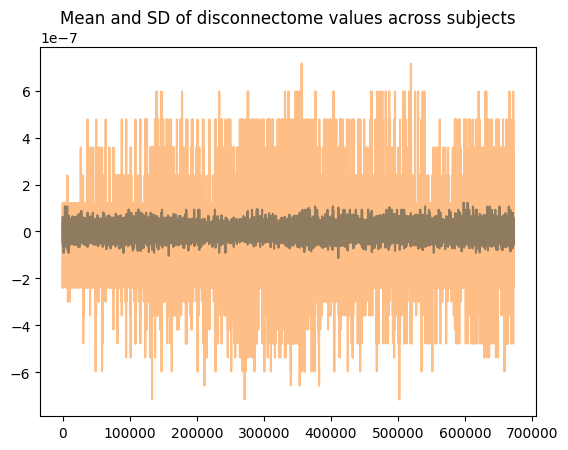

In [ ]:
## DATA IS ALREADY ZSCORED, so this is useless here 
# (should be done on raw disconnectomes prior to zscoring)
#check all_data for locations where there is no disconnectome

# vox_pct_thresh = .15 #amount of disconnection to cut at
# _ = plt.hist((all_data<vox_pct_thresh).sum(axis=0),bins=10)
# (all_data>vox_pct_thresh).sum(axis=0)
plt.plot(all_data.mean(axis=0))
plt.plot(all_data.std(axis=0)-1,alpha=0.5)
plt.title('Mean and SD of disconnectome values across voxels')


In [ ]:
# appx 30-40k / hr
# parallelized appx 17k in 5 mins
_df = df_subset.copy()
vox_idx = 0
st = time.time()
for vox_idx in range(all_data.shape[1]):
    if np.mod(vox_idx,10000)==0:
        print(vox_idx,end=',')
    _df['vox_dconn_z'] = all_data[:,vox_idx]
    
    res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',
                    covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()
    
    if vox_idx == 0:
        row_names = [r[0] for r in res]
        M_X = np.zeros((all_data.shape[1],6),dtype=np.float16)
        Y_M = np.zeros_like(M_X)
        tot = np.zeros_like(M_X)
        direct = np.zeros_like(M_X)
        indirect = np.zeros_like(M_X)

    for r in res:
        _d = r[1:]
        if _d[-1] == 'Yes': #convert significance to binary
            _d[-1] = 1
        else:
            _d[-1] = 0
        if r[0] == 'APM Task Score ~ X':
            M_X[vox_idx,:] = _d
        elif r[0] == 'Y ~ APM Task Score':
            Y_M[vox_idx,:] = _d
        elif r[0] == 'Total':
            tot[vox_idx,:] = _d
        elif r[0] == 'Direct':
            direct[vox_idx,:] = _d
        elif r[0] == 'Indirect':
            indirect[vox_idx,:] = _d

et = time.time()
print(f'\nTime elapsed: {et-st:.1f} seconds')
print(f'\nTime elapsed: {(et-st)/60:.1f} minutes')


0,10000,20000,30000,40000,50000,60000,

KeyboardInterrupt: 

In [ ]:
import numpy as np
from joblib import Parallel, delayed

# # invariant arrays
# M = df_subset['APM Task Score'].to_numpy()
# Y = df_subset['VGR Task Score'].to_numpy()
# covar = df_subset[['Age (y)', 'Sex (M=0)']].to_numpy()

n_vox = all_data.shape[1]

def run_single_voxel(vox_idx):
    X = all_data[:, vox_idx]

    # Construct minimal DataFrame only once per worker
    df = df_subset.copy()
    df['vox_dconn_z'] = X

    res = mediation_analysis(
        data=df,
        x='vox_dconn_z',
        m='APM Task Score',
        y='VGR Task Score',
        covar=['Age (y)', 'Sex (M=0)'],
        seed=42
    ).to_numpy()

    # Output buffers (float32 faster & safer than float16)
    M_X = np.zeros(6, dtype=np.float32)
    Y_M = np.zeros(6, dtype=np.float32)
    tot = np.zeros(6, dtype=np.float32)
    direct = np.zeros(6, dtype=np.float32)
    indirect = np.zeros(6, dtype=np.float32)

    for name, *vals in res:
        vals[-1] = 1.0 if vals[-1] == 'Yes' else 0.0

        if name == 'APM Task Score ~ X':
            M_X[:] = vals
        elif name == 'Y ~ APM Task Score':
            Y_M[:] = vals
        elif name == 'Total':
            tot[:] = vals
        elif name == 'Direct':
            direct[:] = vals
        elif name == 'Indirect':
            indirect[:] = vals

    return M_X, Y_M, tot, direct, indirect


In [ ]:
results = Parallel(
    n_jobs=-1,          # use all cores
    backend='loky',
    verbose=10
)(
    delayed(run_single_voxel)(i) for i in range(n_vox)
)

M_X = np.vstack([r[0] for r in results])
Y_M = np.vstack([r[1] for r in results])
tot = np.vstack([r[2] for r in results])
direct = np.vstack([r[3] for r in results])
indirect = np.vstack([r[4] for r in results])



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

In [ ]:
%timeit res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()

109 ms ± 2.86 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [187]:
res2 = run_single_voxel(0)
vox_idx = 0
_df['vox_dconn_z'] = all_data[:,vox_idx]
res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()


In [195]:
for idx,rr in enumerate(res):
    print(f'{rr[2]} {res2[idx][1]}')


0.17166532520794564 0.17166532576084137
0.1447226506999749 0.14472265541553497
0.1824685483196152 0.18246854841709137
0.19001883767958302 0.19001883268356323
0.17033459063854972 0.170334592461586
